# Micro-Lender Credit Scoring

## A Machine Learning Loan Default Risk Predictor

### 1. Project Overview

Micro-lenders require reliable and efficient methods for assessing the repayment risk of prospective borrowers. Poor credit-risk assessment can result in increased loan defaults and financial losses, while overly restrictive lending decisions may exclude potentially creditworthy borrowers.

This project develops a machine-learning prototype for estimating the likelihood of credit default using historical borrower and repayment information. The system is intended as a decision-support tool that produces an interpretable default-risk assessment rather than automatically making lending decisions.

### 2. Problem Statement

Micro-lenders often need to make credit decisions quickly while managing the risk that borrowers may fail to repay their loans. A data-driven credit-scoring approach can support this process by identifying patterns in historical financial and repayment behaviour that are associated with default.

The project therefore investigates whether machine-learning classification techniques can be used to estimate default risk and provide an understandable risk assessment that could support credit evaluation.

### 3. Project Objectives

The objectives of this project are to:

1. Explore and understand the characteristics of the credit dataset.
2. Assess data quality and prepare the dataset for machine-learning analysis.
3. Identify patterns and variables associated with credit default.
4. Develop classification models for predicting default risk.
5. Evaluate and compare the models using appropriate classification metrics.
6. Generate an interpretable probability-based credit-risk assessment.
7. Identify important factors associated with the model's predictions.
8. Demonstrate how the prototype could support micro-lending credit-risk assessment.

### 4. Dataset Description

The dataset contains 30,000 customer records and 25 columns covering demographic characteristics, credit limits, repayment status, bill amounts, previous payment amounts and the default outcome.

The target variable is `default payment next month`, where:

* `0` represents no default.
* `1` represents default.

Initial inspection shows that all 30,000 records contain values across the 25 columns, indicating that there are no missing values in the dataset.

The dataset is being used to develop a prototype credit-risk model. Because the source data do not represent Nigerian micro-lending customers specifically, the resulting model should not be interpreted as a production-ready Nigerian credit-scoring system. Local data, validation and appropriate governance would be required before real-world deployment.


In [ ]:
!pip install xlrd

## 5. Initial Data Exploration

Before performing data cleaning, visualization or machine learning, an initial inspection was conducted to understand the dataset's dimensions, variables, data types, missing values, duplicate records and summary statistics.

In [3]:
import pandas as pd

df = pd.read_excel(
    "default of credit card clients.xls",
    header=1
)

df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [ ]:
# Dataset dimensions
print("Dataset shape:", df.shape)

# Column names
print(df.columns.tolist())

# First five records
display(df.head())

# Data types and missing values
df.info()

# Summary statistics
display(df.describe())

# Missing values
print(df.isnull().sum())

# Duplicate rows
print("Duplicates:", df.duplicated().sum())

Dataset shape: (30000, 25)
['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default payment next month    0
dtype: int64
Duplicates: 0


In [ ]:
df["default payment next month"].value_counts()

,count
default payment next month,
0,23364
1,6636


In [ ]:
df["default payment next month"].value_counts(normalize=True) * 100

,proportion
default payment next month,
0,77.88
1,22.12


In [4]:
print("Total missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Total missing values: 0
Duplicate rows: 0


In [5]:
categorical_columns = [
    "SEX",
    "EDUCATION",
    "MARRIAGE",
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6"
]

for column in categorical_columns:
    print(f"\n--- {column} ---")
    print(df[column].value_counts().sort_index())


--- SEX ---
SEX
1    11888
2    18112
Name: count, dtype: int64

--- EDUCATION ---
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

--- MARRIAGE ---
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64

--- PAY_0 ---
PAY_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64

--- PAY_2 ---
PAY_2
-2     3782
-1     6050
 0    15730
 1       28
 2     3927
 3      326
 4       99
 5       25
 6       12
 7       20
 8        1
Name: count, dtype: int64

--- PAY_3 ---
PAY_3
-2     4085
-1     5938
 0    15764
 1        4
 2     3819
 3      240
 4       76
 5       21
 6       23
 7       27
 8        3
Name: count, dtype: int64

--- PAY_4 ---
PAY_4
-2     4348
-1     5687
 0    16455
 1        2
 2     3159
 3      180
 4       69
 5       35
 6        5
 7       58
 8        2
Name: count, dty

### Data Quality Findings

The initial data-quality assessment identified no missing values and no duplicate records.

Inspection of the categorical variables revealed some uncommon or undocumented category codes. The `EDUCATION` variable contains values 0, 5 and 6 in addition to the main documented categories, while `MARRIAGE` contains a small number of records coded as 0. Rather than deleting these observations, the uncommon education categories will be consolidated into an "Other/Unknown" category, while the uncommon marriage categories will similarly be grouped as "Other/Unknown".

The repayment-status (`PAY_*`) variables contain negative, zero and positive values. These variables represent repayment-status codes rather than ordinary continuous measurements; therefore, their values will be retained and interpreted according to their repayment-status meaning rather than treated as numerical outliers.

In [6]:
# Create a copy for cleaning
data = df.copy()

# Rename the target variable
data = data.rename(
    columns={"default payment next month": "DEFAULT"}
)

# Remove ID because it is only a record identifier
data = data.drop(columns=["ID"])

print("Cleaned working dataset shape:", data.shape)

Cleaned working dataset shape: (30000, 24)


In [7]:
# Consolidate undocumented education codes into Other/Unknown (4)
data["EDUCATION"] = data["EDUCATION"].replace({
    0: 4,
    5: 4,
    6: 4
})

# Consolidate undocumented/other marriage codes into Other/Unknown (3)
data["MARRIAGE"] = data["MARRIAGE"].replace({
    0: 3
})

In [8]:
print("EDUCATION after cleaning:")
print(data["EDUCATION"].value_counts().sort_index())

print("\nMARRIAGE after cleaning:")
print(data["MARRIAGE"].value_counts().sort_index())

EDUCATION after cleaning:
EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64

MARRIAGE after cleaning:
MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64


In [9]:
print("Dataset shape:", data.shape)
print("Missing values:", data.isnull().sum().sum())
print("Duplicate rows:", data.duplicated().sum())

print("\nTarget distribution:")
print(data["DEFAULT"].value_counts())

print("\nTarget distribution (%):")
print(
    data["DEFAULT"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Dataset shape: (30000, 24)
Missing values: 0
Duplicate rows: 35

Target distribution:
DEFAULT
0    23364
1     6636
Name: count, dtype: int64

Target distribution (%):
DEFAULT
0    77.88
1    22.12
Name: proportion, dtype: float64


### Duplicate Handling

The original dataset contained no duplicate rows when the unique customer ID was included. However, after removing the ID variable, 35 records were found to be exact duplicates across all remaining features and the target variable. These duplicate observations were removed from the working dataset to prevent repeated identical records from unnecessarily influencing the analysis and model training.

In [10]:
# Remove exact duplicate observations
data = data.drop_duplicates().reset_index(drop=True)

print("Dataset shape after removing duplicates:", data.shape)
print("Remaining duplicate rows:", data.duplicated().sum())

Dataset shape after removing duplicates: (29965, 24)
Remaining duplicate rows: 0


In [11]:
print(
    data["DEFAULT"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

DEFAULT
0    77.87
1    22.13
Name: proportion, dtype: float64


## 6. Exploratory Data Analysis

Exploratory Data Analysis (EDA) was conducted to understand the distribution of the target variable and investigate relationships between borrower characteristics, credit behaviour and default risk.

Particular attention was given to repayment history, credit limits, demographic characteristics and previous payment behaviour because these variables may contain useful information for identifying customers with higher default risk.

In [12]:
import matplotlib.pyplot as plt

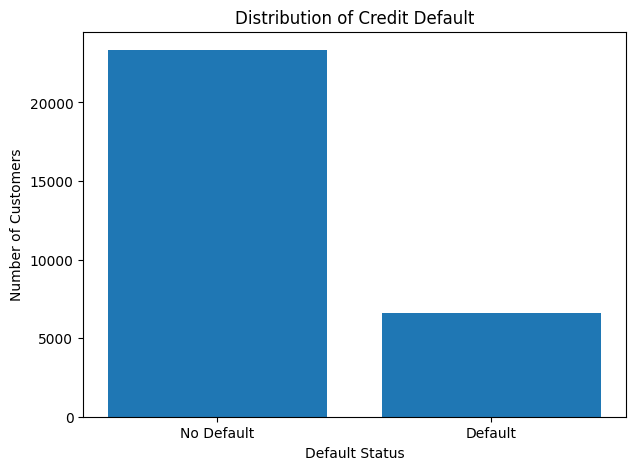

In [13]:
default_counts = data["DEFAULT"].value_counts().sort_index()

plt.figure(figsize=(7, 5))

plt.bar(
    ["No Default", "Default"],
    default_counts.values
)

plt.title("Distribution of Credit Default")
plt.xlabel("Default Status")
plt.ylabel("Number of Customers")

plt.show()

### Interpretation

The target variable is moderately imbalanced. Most customers did not default, while a substantially smaller proportion defaulted. Approximately 22% of the observations belong to the default class.

This imbalance means that model performance should not be assessed using accuracy alone. Metrics such as precision, recall, F1-score, ROC-AUC and the confusion matrix will also be considered, particularly because correctly identifying customers at risk of default is important for credit-risk assessment.

In [14]:
education_labels = {
    1: "Graduate School",
    2: "University",
    3: "High School",
    4: "Other/Unknown"
}

education_default = (
    data.groupby("EDUCATION")["DEFAULT"]
    .mean()
    .mul(100)
)

education_default.index = education_default.index.map(education_labels)

print(education_default.round(2))

EDUCATION
Graduate School    19.24
University         23.74
High School        25.17
Other/Unknown       7.05
Name: DEFAULT, dtype: float64


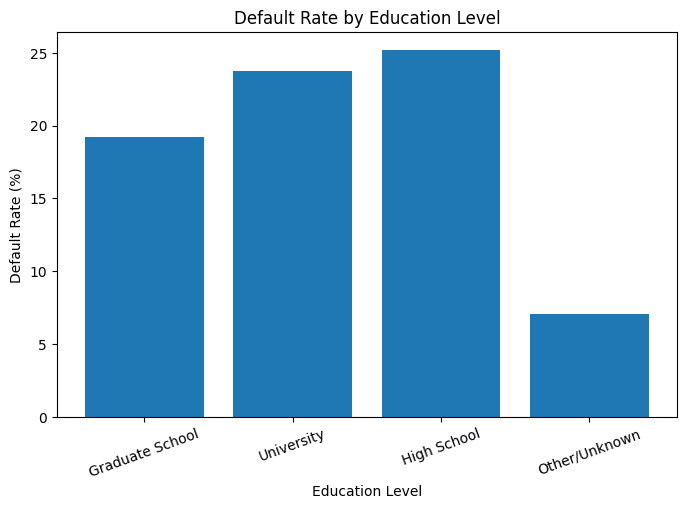

In [15]:
plt.figure(figsize=(8, 5))

plt.bar(
    education_default.index,
    education_default.values
)

plt.title("Default Rate by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Default Rate (%)")

plt.xticks(rotation=20)
plt.show()

In [16]:
marriage_labels = {
    1: "Married",
    2: "Single",
    3: "Other/Unknown"
}

marriage_default = (
    data.groupby("MARRIAGE")["DEFAULT"]
    .mean()
    .mul(100)
)

marriage_default.index = marriage_default.index.map(marriage_labels)

print(marriage_default.round(2))

MARRIAGE
Married          23.46
Single           20.95
Other/Unknown    23.61
Name: DEFAULT, dtype: float64


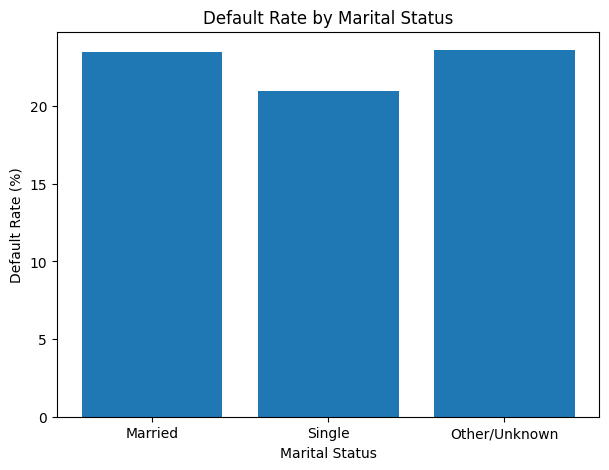

In [17]:
plt.figure(figsize=(7, 5))

plt.bar(
    marriage_default.index,
    marriage_default.values
)

plt.title("Default Rate by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Default Rate (%)")

plt.show()

### Interpretation: Education and Default

Default rates vary across education categories. Customers in the High School category recorded the highest default rate at approximately 25.17%, followed by University customers at 23.74%. Graduate School customers had a lower default rate of approximately 19.24%.

The Other/Unknown category recorded a substantially lower default rate of approximately 7.05%. However, this category contains relatively few observations compared with the major education groups, so this result should be interpreted cautiously.

Overall, the results suggest an association between education category and default in this dataset, but they do not establish that education itself causes differences in default risk.

### Interpretation: Marital Status and Default

Default rates show relatively modest differences across marital-status categories. Married customers recorded a default rate of approximately 23.46%, compared with 20.95% among single customers. The Other/Unknown category recorded approximately 23.61%.

The difference between married and single customers is relatively small compared with the overall variation that may exist in financial and repayment-behaviour variables. Therefore, marital status alone is unlikely to provide sufficient information for assessing credit risk.

In [18]:
credit_summary = (
    data.groupby("DEFAULT")["LIMIT_BAL"]
    .agg(["mean", "median"])
)

credit_summary.index = ["No Default", "Default"]

print(credit_summary.round(2))

                 mean    median
No Default  178084.51  150000.0
Default     129984.57   90000.0


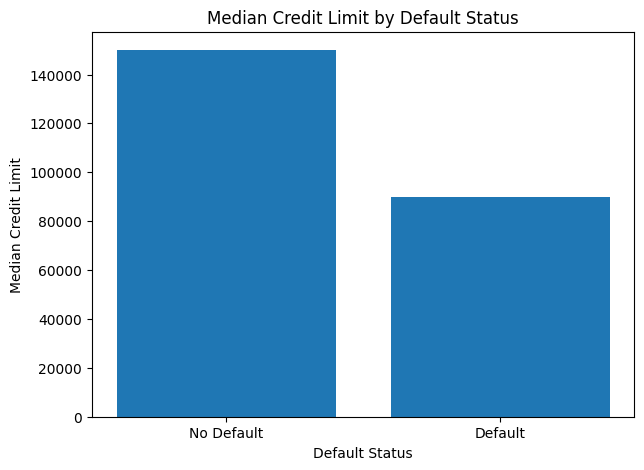

In [19]:
median_credit = (
    data.groupby("DEFAULT")["LIMIT_BAL"]
    .median()
)

plt.figure(figsize=(7, 5))

plt.bar(
    ["No Default", "Default"],
    median_credit.values
)

plt.title("Median Credit Limit by Default Status")
plt.xlabel("Default Status")
plt.ylabel("Median Credit Limit")

plt.show()

In [20]:
age_bins = [20, 29, 39, 49, 59, 100]
age_labels = ["20-29", "30-39", "40-49", "50-59", "60+"]

data["AGE_GROUP"] = pd.cut(
    data["AGE"],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

age_default = (
    data.groupby("AGE_GROUP", observed=False)["DEFAULT"]
    .mean()
    .mul(100)
)

print(age_default.round(2))

AGE_GROUP
20-29    22.87
30-39    20.27
40-49    22.94
50-59    24.86
60+      28.32
Name: DEFAULT, dtype: float64


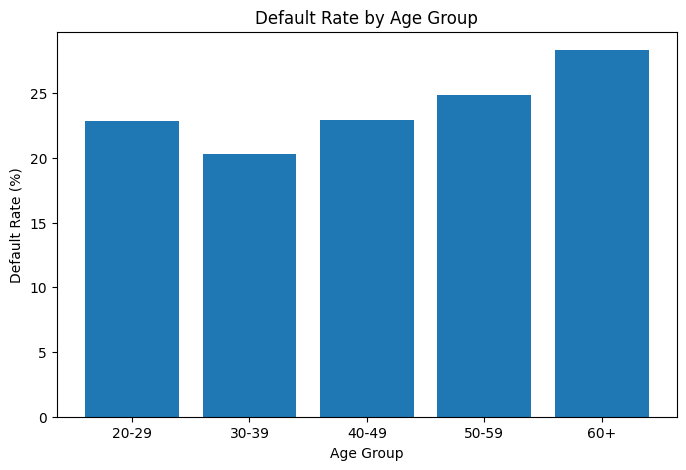

In [21]:
plt.figure(figsize=(8, 5))

plt.bar(
    age_default.index.astype(str),
    age_default.values
)

plt.title("Default Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Default Rate (%)")

plt.show()

In [22]:
pay0_default = (
    data.groupby("PAY_0")["DEFAULT"]
    .agg(["count", "mean"])
)

pay0_default["default_rate_percent"] = (
    pay0_default["mean"] * 100
)

print(
    pay0_default[
        ["count", "default_rate_percent"]
    ].round(2)
)

       count  default_rate_percent
PAY_0                             
-2      2750                 13.24
-1      5682                 16.79
 0     14737                 12.81
 1      3667                 34.03
 2      2666                 69.13
 3       322                 75.78
 4        76                 68.42
 5        26                 50.00
 6        11                 54.55
 7         9                 77.78
 8        19                 57.89


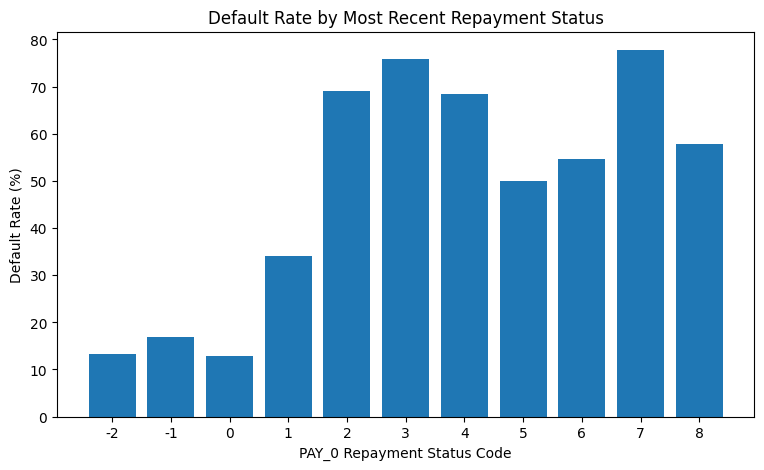

In [23]:
 plt.figure(figsize=(9, 5))

plt.bar(
    pay0_default.index.astype(str),
    pay0_default["default_rate_percent"]
)

plt.title("Default Rate by Most Recent Repayment Status")
plt.xlabel("PAY_0 Repayment Status Code")
plt.ylabel("Default Rate (%)")

plt.show()

### Interpretation: Credit Limit and Default

Customers who did not default had a higher average credit limit of approximately 179,805, compared with approximately 129,985 among customers who defaulted.

The difference is also visible in the median credit limits: the median for non-defaulting customers was 150,000, while the median for defaulting customers was 90,000.

This indicates that credit limit is associated with default status in the dataset. However, this relationship should not be interpreted as evidence that lower credit limits cause default, since credit limits may themselves reflect other characteristics of a customer's credit profile.

### Interpretation: Age and Default

Default rates vary moderately across age groups. Customers aged 30–39 recorded the lowest default rate at approximately 20.27%, while customers aged 60 and above recorded the highest rate at approximately 28.32%.

After the 30–39 age group, the observed default rate increases across successive age categories, reaching 22.94% for ages 40–49, 24.86% for ages 50–59, and 28.32% for customers aged 60 and above.

This suggests that age has some association with default behaviour in the dataset. However, age alone does not provide enough information to determine an individual's credit risk and should not be interpreted as a causal factor.

### Interpretation: Recent Repayment Status and Default

The most recent repayment status shows a strong relationship with default risk.

Customers with PAY_0 values of -2, -1 and 0 recorded relatively low default rates of approximately 13.24%, 16.79% and 12.81%, respectively. In contrast, the default rate increased sharply to 34.03% for PAY_0 = 1 and 69.13% for PAY_0 = 2.

Customers with PAY_0 = 3 recorded an even higher default rate of approximately 75.78%.

This pattern suggests that recent repayment difficulties are strongly associated with subsequent default and may therefore provide important predictive information for the credit-scoring model.

Some of the more extreme PAY_0 categories contain very few customers. Their percentages should therefore be interpreted cautiously because estimates based on small groups can be unstable.

### Repayment Behaviour Across Six Months

To examine the customer's broader repayment behaviour, the six repayment-status variables were combined to calculate the number of months in which each customer recorded a positive repayment-status code. This provides a simple measure of the frequency of repayment difficulties during the observed period.

In [25]:
pay_columns = [
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6"
]

data["DELAY_MONTHS"] = (
    data[pay_columns] > 0
).sum(axis=1)

print(data["DELAY_MONTHS"].value_counts().sort_index())

DELAY_MONTHS
0    19918
1     4405
2     1899
3     1154
4      951
5      298
6     1340
Name: count, dtype: int64


In [26]:
delay_default = (
    data.groupby("DELAY_MONTHS")["DEFAULT"]
    .agg(["count", "mean"])
)

delay_default["default_rate_percent"] = (
    delay_default["mean"] * 100
)

print(
    delay_default[
        ["count", "default_rate_percent"]
    ].round(2)
)

              count  default_rate_percent
DELAY_MONTHS                             
0             19918                 11.71
1              4405                 29.88
2              1899                 38.76
3              1154                 50.87
4               951                 57.31
5               298                 57.38
6              1340                 70.30


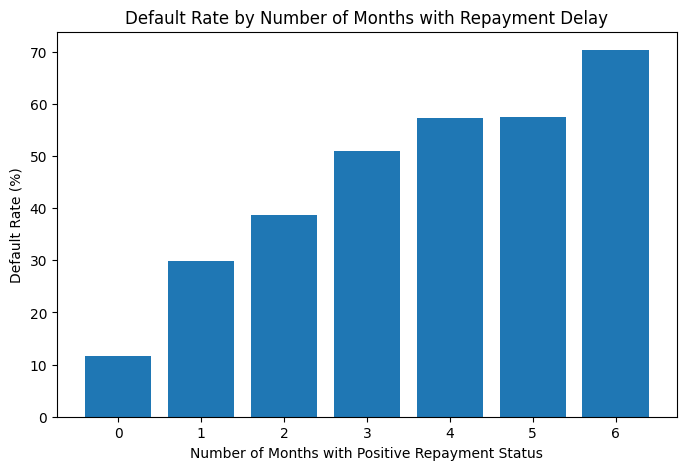

In [27]:
plt.figure(figsize=(8, 5))

plt.bar(
    delay_default.index.astype(str),
    delay_default["default_rate_percent"]
)

plt.title("Default Rate by Number of Months with Repayment Delay")
plt.xlabel("Number of Months with Positive Repayment Status")
plt.ylabel("Default Rate (%)")

plt.show()

In [28]:
payment_summary = (
    data.groupby("DEFAULT")["PAY_AMT1"]
    .agg(["mean", "median"])
)

payment_summary.index = ["No Default", "Default"]

print(payment_summary.round(2))

               mean  median
No Default  6315.05  2474.0
Default     3400.12  1641.0


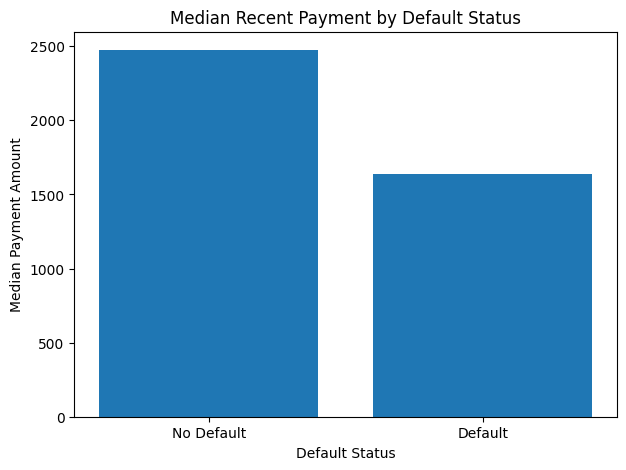

In [29]:
median_payment = (
    data.groupby("DEFAULT")["PAY_AMT1"]
    .median()
)

plt.figure(figsize=(7, 5))

plt.bar(
    ["No Default", "Default"],
    median_payment.values
)

plt.title("Median Recent Payment by Default Status")
plt.xlabel("Default Status")
plt.ylabel("Median Payment Amount")

plt.show()

### Interpretation: Repayment History and Default Risk

A strong relationship is observed between the frequency of repayment difficulties and subsequent default.

Customers with no months of positive repayment-status codes recorded a default rate of approximately 11.71%. The default rate increased to 29.88% for customers with one such month and continued rising as the number of months increased.

Customers with positive repayment-status codes in three months had a default rate of approximately 50.87%, while customers with positive codes in all six observed months recorded the highest default rate at approximately 70.30%.

This pattern indicates that persistent repayment difficulty is strongly associated with future default. The engineered `DELAY_MONTHS` feature therefore captures useful information about repayment consistency and may be valuable for the predictive model.

### Interpretation: Recent Payment Amount and Default

Customers who did not default made larger recent payments than customers who defaulted.

The mean recent payment amount among non-defaulting customers was approximately 6,315, compared with approximately 3,400 among defaulting customers. Similarly, the median recent payment was 2,474 for non-defaulting customers and 1,641 for defaulting customers.

This suggests that recent payment behaviour contains useful information about default risk. Customers making smaller payments may have greater repayment difficulty, although payment amount should be considered together with outstanding balances, credit limits and repayment history rather than interpreted independently.

In [30]:
# Recent credit utilization ratio
data["CREDIT_UTILIZATION"] = (
    data["BILL_AMT1"] / data["LIMIT_BAL"]
)

# Inspect the distribution
print(data["CREDIT_UTILIZATION"].describe())

count    29965.000000
mean         0.424263
std          0.411451
min         -0.619892
25%          0.022300
50%          0.315278
75%          0.830325
max          6.455300
Name: CREDIT_UTILIZATION, dtype: float64


In [31]:
utilization_summary = (
    data.groupby("DEFAULT")["CREDIT_UTILIZATION"]
    .agg(["mean", "median"])
)

utilization_summary.index = ["No Default", "Default"]

print(utilization_summary.round(3))

             mean  median
No Default  0.405   0.269
Default     0.491   0.494


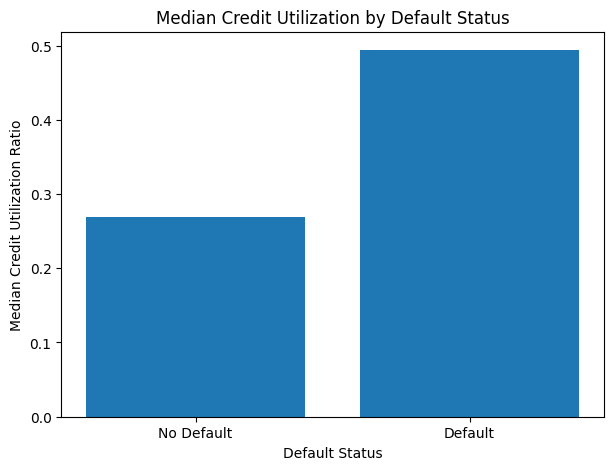

In [32]:
median_utilization = (
    data.groupby("DEFAULT")["CREDIT_UTILIZATION"]
    .median()
)

plt.figure(figsize=(7, 5))

plt.bar(
    ["No Default", "Default"],
    median_utilization.values
)

plt.title("Median Credit Utilization by Default Status")
plt.xlabel("Default Status")
plt.ylabel("Median Credit Utilization Ratio")

plt.show()

### Interpretation: Credit Utilization and Default

Customers who defaulted showed higher recent credit utilization than customers who did not default.

The median credit utilization ratio was approximately 0.494 (49.4%) among defaulting customers, compared with approximately 0.269 (26.9%) among non-defaulting customers. The mean utilization ratio was also higher for the default group.

This suggests that customers using a larger proportion of their available credit may be associated with greater default risk. Credit utilization may therefore provide useful predictive information when combined with repayment history, payment behaviour and other financial characteristics.

## 7. Predictive Modeling

The next stage develops machine-learning models to estimate the probability that a customer will default.

The modeling process includes feature preparation, separation of the dataset into training and testing samples, model training and evaluation using multiple classification metrics.

Because the target variable is imbalanced, model performance will be evaluated using precision, recall, F1-score, confusion matrix and ROC-AUC in addition to accuracy.

In [33]:
# Financial and repayment-behaviour features
behavior_features = [
    "LIMIT_BAL",
    "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6",
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3",
    "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3",
    "PAY_AMT4", "PAY_AMT5", "PAY_AMT6",
    "DELAY_MONTHS",
    "CREDIT_UTILIZATION"
]

X = data[behavior_features]
y = data["DEFAULT"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeatures:")
print(X.columns.tolist())

Feature matrix shape: (29965, 21)
Target shape: (29965,)

Features:
['LIMIT_BAL', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'DELAY_MONTHS', 'CREDIT_UTILIZATION']


In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("\nTraining target distribution (%):")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nTesting target distribution (%):")
print(y_test.value_counts(normalize=True).mul(100).round(2))

Training features: (23972, 21)
Testing features: (5993, 21)

Training target distribution (%):
DEFAULT
0    77.87
1    22.13
Name: proportion, dtype: float64

Testing target distribution (%):
DEFAULT
0    77.87
1    22.13
Name: proportion, dtype: float64


In [35]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

print("Logistic Regression training complete.")

Logistic Regression training complete.


In [36]:
y_pred_logistic = logistic_model.predict(X_test)

y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]

print("Predictions generated:", len(y_pred_logistic))

Predictions generated: 5993


In [37]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Logistic Regression Results")
print("-" * 35)

print("Accuracy:",
      round(accuracy_score(y_test, y_pred_logistic), 3))

print("Precision:",
      round(precision_score(y_test, y_pred_logistic), 3))

print("Recall:",
      round(recall_score(y_test, y_pred_logistic), 3))

print("F1 Score:",
      round(f1_score(y_test, y_pred_logistic), 3))

print("ROC-AUC:",
      round(roc_auc_score(y_test, y_prob_logistic), 3))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_logistic))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic))

Logistic Regression Results
-----------------------------------
Accuracy: 0.766
Precision: 0.475
Recall: 0.56
F1 Score: 0.514
ROC-AUC: 0.747

Confusion Matrix:
[[3846  821]
 [ 583  743]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.82      0.85      4667
           1       0.48      0.56      0.51      1326

    accuracy                           0.77      5993
   macro avg       0.67      0.69      0.68      5993
weighted avg       0.78      0.77      0.77      5993



### Baseline Model Interpretation

The Logistic Regression model achieved an accuracy of approximately **76.6%** and a ROC-AUC score of **0.747**.

For the default class, the model achieved a precision of approximately **47.5%**, recall of **56.0%**, and an F1-score of **51.4%**. This means the model identified slightly more than half of the customers who actually defaulted.

The confusion matrix shows that 743 actual defaulters were correctly identified, while 583 defaulters were incorrectly classified as non-defaulters. Because missed defaults can represent financial risk to a lender, recall and ROC-AUC are important evaluation measures alongside overall accuracy.

The Logistic Regression model therefore provides a useful baseline against which a more flexible machine-learning model can be compared.

### 7.2 Random Forest Classifier

A Random Forest classifier was trained as a second predictive model. Unlike Logistic Regression, Random Forest can capture nonlinear relationships and interactions among borrower repayment and financial characteristics.

Class weighting was used to account for the imbalance between defaulting and non-defaulting customers.

In [38]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train, y_train)

print("Random Forest training complete.")

Random Forest training complete.


In [39]:
y_pred_rf = random_forest_model.predict(X_test)
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

print("Random Forest predictions generated:", len(y_pred_rf))

Random Forest predictions generated: 5993


In [40]:
print("Random Forest Results")
print("-" * 35)

print("Accuracy:",
      round(accuracy_score(y_test, y_pred_rf), 3))

print("Precision:",
      round(precision_score(y_test, y_pred_rf), 3))

print("Recall:",
      round(recall_score(y_test, y_pred_rf), 3))

print("F1 Score:",
      round(f1_score(y_test, y_pred_rf), 3))

print("ROC-AUC:",
      round(roc_auc_score(y_test, y_prob_rf), 3))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Results
-----------------------------------
Accuracy: 0.779
Precision: 0.501
Recall: 0.578
F1 Score: 0.537
ROC-AUC: 0.774

Confusion Matrix:
[[3902  765]
 [ 559  767]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.84      0.85      4667
           1       0.50      0.58      0.54      1326

    accuracy                           0.78      5993
   macro avg       0.69      0.71      0.70      5993
weighted avg       0.79      0.78      0.78      5993



In [41]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_logistic),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_logistic),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_logistic),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_logistic),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

model_comparison.round(3)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.766,0.475,0.560,0.514,0.747
1,Random Forest,0.779,0.501,0.578,0.537,0.774


### Model Selection

Two classification algorithms were evaluated: Logistic Regression and Random Forest.

The Random Forest model produced the stronger overall performance, achieving an accuracy of **77.9%**, precision of **50.1%**, recall of **57.8%**, F1-score of **53.7%**, and ROC-AUC of **77.4%**.

Compared with Logistic Regression, Random Forest achieved improvements across all five evaluation metrics. Of particular importance for credit-risk assessment, Random Forest obtained higher recall and ROC-AUC, indicating better identification of customers who may default and better overall discrimination between lower-risk and higher-risk borrowers.

Based on these results, the **Random Forest classifier was selected as the final predictive model** for the Micro-Lender Credit Scoring system.

### 7.3 Feature Importance

To improve the interpretability of the selected Random Forest model, feature importance scores were examined. These scores indicate which borrower characteristics contributed most strongly to the model's predictions.

In [42]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": random_forest_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

feature_importance.head(10)

,Feature,Importance
0,PAY_0,0.184265
1,DELAY_MONTHS,0.149243
2,PAY_2,0.081452
3,PAY_3,0.048347
4,CREDIT_UTILIZATION,0.046932
5,PAY_4,0.040191
6,PAY_AMT1,0.040148
7,LIMIT_BAL,0.039825
8,BILL_AMT1,0.038681
9,PAY_AMT2,0.036594


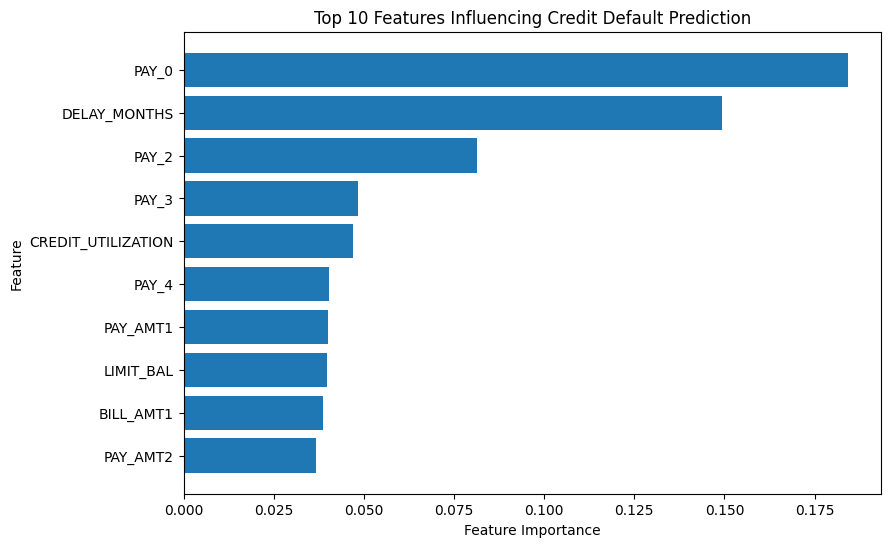

In [43]:
top_features = feature_importance.head(10).sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 10 Features Influencing Credit Default Prediction")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()

### Feature Importance Interpretation

The Random Forest feature-importance analysis indicates that repayment behaviour is one of the strongest signals for predicting credit default.

The most influential individual feature is `PAY_0`, which represents the customer's most recent repayment status. The engineered `DELAY_MONTHS` feature is the second most important predictor, demonstrating that repeated repayment difficulties across several months provide valuable information about future default risk.

Other important predictors include previous repayment-status variables, credit utilization, recent payment amounts, credit limit and outstanding bill amounts.

Overall, the results suggest that a borrower's recent and historical repayment behaviour provides stronger predictive information for credit-risk assessment than relying solely on demographic characteristics.

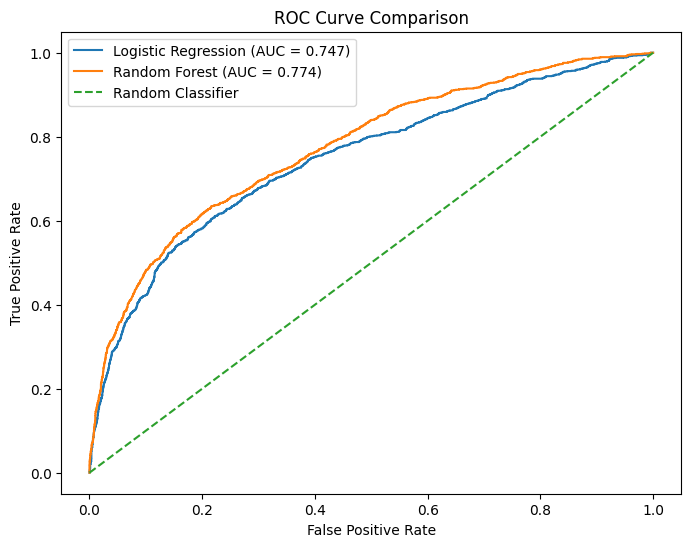

In [44]:
from sklearn.metrics import roc_curve, auc

fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_logistic)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

auc_log = auc(fpr_log, tpr_log)
auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_log,
    tpr_log,
    label=f"Logistic Regression (AUC = {auc_log:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {auc_rf:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

### ROC-AUC Interpretation

The ROC curve compares the ability of the two classification models to distinguish between customers who default and those who do not.

Logistic Regression achieved a ROC-AUC score of approximately **0.747**, while Random Forest achieved a higher score of approximately **0.774**.

Since an AUC of 0.5 represents random classification and higher values indicate better discrimination, both models demonstrate useful predictive ability. However, Random Forest provides stronger discrimination and was therefore retained as the final model.

In [45]:
random_forest_model.predict_proba(X_test)[:, 1]

array([0.33847237, 0.17807263, 0.33816215, ..., 0.36936574, 0.36347359,
       0.33457481])

## 8. Micro-Lender Credit Scoring System

The final Random Forest model produces an estimated probability that each customer will default. To make this prediction easier for a lender to interpret, the default probability is converted into a credit-risk score ranging from 0 to 100.

The score is calculated as:

**Credit Score = (1 − Predicted Probability of Default) × 100**

A higher score therefore represents lower estimated credit risk, while a lower score represents higher estimated credit risk.

For demonstration purposes, customers are grouped into three risk categories:

- **Low Risk:** Credit Score ≥ 70
- **Medium Risk:** Credit Score from 40 to 69
- **High Risk:** Credit Score < 40

These thresholds are illustrative MVP decision bands rather than regulatory or production lending thresholds. In a real lending environment, thresholds should be calibrated using portfolio performance, expected losses, business objectives, fairness analysis and applicable lending regulations.

In [46]:
credit_results = X_test.copy()

credit_results["ACTUAL_DEFAULT"] = y_test.values
credit_results["DEFAULT_PROBABILITY"] = y_prob_rf

credit_results["CREDIT_SCORE"] = (
    (1 - credit_results["DEFAULT_PROBABILITY"]) * 100
).round(0).astype(int)

credit_results[
    ["ACTUAL_DEFAULT", "DEFAULT_PROBABILITY", "CREDIT_SCORE"]
].head(10)

,ACTUAL_DEFAULT,DEFAULT_PROBABILITY,CREDIT_SCORE
8681,0,0.338472,66
24179,0,0.178073,82
27755,0,0.338162,66
14938,0,0.398461,60
1486,0,0.104325,90
1139,0,0.176434,82
26456,0,0.397888,60
27719,0,0.276170,72
1071,1,0.224561,78
6988,0,0.192707,81


In [47]:
def assign_risk_category(score):
    if score >= 70:
        return "Low Risk"
    elif score >= 40:
        return "Medium Risk"
    else:
        return "High Risk"


credit_results["RISK_CATEGORY"] = (
    credit_results["CREDIT_SCORE"]
    .apply(assign_risk_category)
)

credit_results[
    [
        "ACTUAL_DEFAULT",
        "DEFAULT_PROBABILITY",
        "CREDIT_SCORE",
        "RISK_CATEGORY"
    ]
].head(10)

,ACTUAL_DEFAULT,DEFAULT_PROBABILITY,CREDIT_SCORE,RISK_CATEGORY
8681,0,0.338472,66,Medium Risk
24179,0,0.178073,82,Low Risk
27755,0,0.338162,66,Medium Risk
14938,0,0.398461,60,Medium Risk
1486,0,0.104325,90,Low Risk
1139,0,0.176434,82,Low Risk
26456,0,0.397888,60,Medium Risk
27719,0,0.276170,72,Low Risk
1071,1,0.224561,78,Low Risk
6988,0,0.192707,81,Low Risk


In [48]:
risk_distribution = (
    credit_results["RISK_CATEGORY"]
    .value_counts()
    .reindex(["Low Risk", "Medium Risk", "High Risk"])
)

print(risk_distribution)

print("\nPercentage distribution:")
print(
    (
        risk_distribution /
        risk_distribution.sum() * 100
    ).round(2)
)

RISK_CATEGORY
Low Risk       2472
Medium Risk    2394
High Risk      1127
Name: count, dtype: int64

Percentage distribution:
RISK_CATEGORY
Low Risk       41.25
Medium Risk    39.95
High Risk      18.81
Name: count, dtype: float64


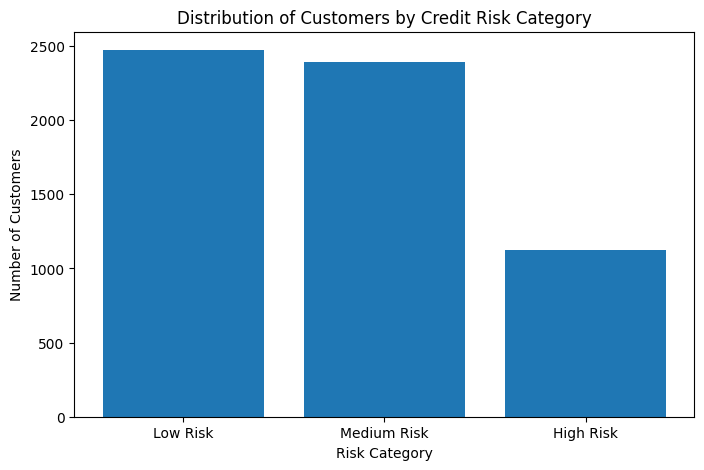

In [49]:
plt.figure(figsize=(8, 5))

plt.bar(
    risk_distribution.index,
    risk_distribution.values
)

plt.title("Distribution of Customers by Credit Risk Category")
plt.xlabel("Risk Category")
plt.ylabel("Number of Customers")

plt.show()

In [50]:
risk_validation = (
    credit_results
    .groupby("RISK_CATEGORY")["ACTUAL_DEFAULT"]
    .agg(["count", "mean"])
)

risk_validation["ACTUAL_DEFAULT_RATE_%"] = (
    risk_validation["mean"] * 100
).round(2)

risk_validation = risk_validation[
    ["count", "ACTUAL_DEFAULT_RATE_%"]
]

risk_validation

,count,ACTUAL_DEFAULT_RATE_%
RISK_CATEGORY,,
High Risk,1127,57.05
Low Risk,2472,8.09
Medium Risk,2394,20.18


### Credit Risk Segmentation Validation

The proposed credit-scoring system successfully separates customers into groups with substantially different observed default rates.

Customers classified as **Low Risk** recorded an actual default rate of approximately **8.09%**, while the **Medium Risk** group recorded a default rate of approximately **20.18%**. The **High Risk** group had a considerably higher observed default rate of approximately **57.05%**.

This increasing pattern provides evidence that the model-derived credit score is useful for ranking borrowers according to relative credit risk. Customers receiving lower credit scores are substantially more likely to default than customers receiving higher scores.

The risk thresholds used in this project are illustrative MVP thresholds and would require further calibration before use in a real lending environment.

### 8.1 Lending Decision Support

To demonstrate how the credit score could support a micro-lender, each risk category is mapped to a simple decision-support recommendation.

- **Low Risk:** Consider for Approval
- **Medium Risk:** Manual Review
- **High Risk:** High Risk / Further Assessment

These recommendations are intended only as an MVP demonstration. A real lending decision should incorporate additional affordability checks, verified borrower information, business rules, fairness considerations and applicable lending regulations.

In [51]:
def lending_recommendation(risk_category):
    if risk_category == "Low Risk":
        return "Consider for Approval"
    elif risk_category == "Medium Risk":
        return "Manual Review"
    else:
        return "High Risk / Further Assessment"


credit_results["RECOMMENDATION"] = (
    credit_results["RISK_CATEGORY"]
    .apply(lending_recommendation)
)

credit_results[
    [
        "DEFAULT_PROBABILITY",
        "CREDIT_SCORE",
        "RISK_CATEGORY",
        "RECOMMENDATION"
    ]
].head(10)

,DEFAULT_PROBABILITY,CREDIT_SCORE,RISK_CATEGORY,RECOMMENDATION
8681,0.338472,66,Medium Risk,Manual Review
24179,0.178073,82,Low Risk,Consider for Approval
27755,0.338162,66,Medium Risk,Manual Review
14938,0.398461,60,Medium Risk,Manual Review
1486,0.104325,90,Low Risk,Consider for Approval
1139,0.176434,82,Low Risk,Consider for Approval
26456,0.397888,60,Medium Risk,Manual Review
27719,0.276170,72,Low Risk,Consider for Approval
1071,0.224561,78,Low Risk,Consider for Approval
6988,0.192707,81,Low Risk,Consider for Approval


In [52]:
demo_results = credit_results[
    [
        "DEFAULT_PROBABILITY",
        "CREDIT_SCORE",
        "RISK_CATEGORY",
        "RECOMMENDATION"
    ]
].copy()

demo_results["DEFAULT_PROBABILITY"] = (
    demo_results["DEFAULT_PROBABILITY"] * 100
).round(2)

demo_results = demo_results.rename(
    columns={
        "DEFAULT_PROBABILITY": "DEFAULT_RISK_%"
    }
)

demo_results.head(10)

,DEFAULT_RISK_%,CREDIT_SCORE,RISK_CATEGORY,RECOMMENDATION
8681,33.85,66,Medium Risk,Manual Review
24179,17.81,82,Low Risk,Consider for Approval
27755,33.82,66,Medium Risk,Manual Review
14938,39.85,60,Medium Risk,Manual Review
1486,10.43,90,Low Risk,Consider for Approval
1139,17.64,82,Low Risk,Consider for Approval
26456,39.79,60,Medium Risk,Manual Review
27719,27.62,72,Low Risk,Consider for Approval
1071,22.46,78,Low Risk,Consider for Approval
6988,19.27,81,Low Risk,Consider for Approval


In [53]:
decision_summary = (
    credit_results["RECOMMENDATION"]
    .value_counts()
)

decision_summary

,count
RECOMMENDATION,
Consider for Approval,2472
Manual Review,2394
High Risk / Further Assessment,1127


In [54]:
print("Original df rows:", len(df))
print("Working data rows:", len(data))

print("\nMissing values in CREDIT_UTILIZATION:")
print(data["CREDIT_UTILIZATION"].isna().sum())

print("\nInfinite values:")
import numpy as np
print(np.isinf(data["CREDIT_UTILIZATION"]).sum())

print("\nRows currently in X:", len(X))

Original df rows: 30000
Working data rows: 29965

Missing values in CREDIT_UTILIZATION:
0

Infinite values:
0

Rows currently in X: 29965


### 8.2 Data Retention Check

A final data-retention check was performed to account for the difference between the original dataset size and the modelling dataset. This ensures that any observations excluded during preprocessing are explicitly identified and documented.

In [55]:
# Compare original and working dataset indices
missing_indices = df.index.difference(data.index)

print("Rows in original dataset:", len(df))
print("Rows in modelling dataset:", len(data))
print("Rows excluded:", len(missing_indices))

print("\nExcluded row indices:")
print(missing_indices.tolist())

# Inspect excluded observations
df.loc[missing_indices]

Rows in original dataset: 30000
Rows in modelling dataset: 29965
Rows excluded: 35

Excluded row indices:
[29965, 29966, 29967, 29968, 29969, 29970, 29971, 29972, 29973, 29974, 29975, 29976, 29977, 29978, 29979, 29980, 29981, 29982, 29983, 29984, 29985, 29986, 29987, 29988, 29989, 29990, 29991, 29992, 29993, 29994, 29995, 29996, 29997, 29998, 29999]


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
29965,29966,140000,1,2,1,32,0,0,0,0,...,137450,135638,136375,6300,6500,6300,6000,5200,5000,0
29966,29967,150000,1,5,2,31,2,0,0,0,...,0,0,0,4633,2000,0,0,0,0,1
29967,29968,50000,1,2,1,32,0,0,0,-1,...,50551,40590,39384,2686,0,50551,0,1600,1500,0
29968,29969,20000,1,2,2,34,0,0,0,0,...,13478,16978,12914,2000,2000,1000,5000,12914,600,0
29969,29970,200000,1,2,1,33,0,0,0,0,...,56768,58826,67577,5000,2183,2059,3000,9751,3000,0
29970,29971,360000,1,1,1,34,-1,-1,-1,0,...,49005,8676,19487,52951,64535,8907,53,19584,16080,0
29971,29972,80000,1,3,1,36,0,0,0,0,...,69674,71070,73612,2395,2500,2530,2556,3700,3000,0
29972,29973,190000,1,1,1,37,0,0,0,0,...,29223,19616,148482,2000,3869,25128,10115,148482,4800,0
29973,29974,230000,1,2,1,35,1,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,1
29974,29975,50000,1,2,1,37,1,2,2,2,...,2846,1585,1324,0,3000,0,0,1000,1000,1


In [56]:
# Check original rows for unusual values in variables
# involved in feature engineering

columns_to_check = [
    "LIMIT_BAL",
    "BILL_AMT1",
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6"
]

df.loc[missing_indices, columns_to_check]

,LIMIT_BAL,BILL_AMT1,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
29965,140000,134236,0,0,0,0,0,0
29966,150000,134866,2,0,0,0,-2,-2
29967,50000,50564,0,0,0,-1,2,0
29968,20000,13730,0,0,0,0,0,-1
29969,200000,110006,0,0,0,0,0,0
29970,360000,33654,-1,-1,-1,0,0,-1
29971,80000,65554,0,0,0,0,0,0
29972,190000,21628,0,0,0,0,0,-1
29973,230000,0,1,-2,-2,-2,-2,-2
29974,50000,10904,1,2,2,2,0,0


In [57]:
print("df shape:", df.shape)
print("data shape:", data.shape)

print("\ndf index range:")
print(df.index.min(), "to", df.index.max())

print("\ndata index range:")
print(data.index.min(), "to", data.index.max())

print("\nLast 10 indices in df:")
print(df.index[-10:].tolist())

print("\nLast 10 indices in data:")
print(data.index[-10:].tolist())

df shape: (30000, 25)
data shape: (29965, 27)

df index range:
0 to 29999

data index range:
0 to 29964

Last 10 indices in df:
[29990, 29991, 29992, 29993, 29994, 29995, 29996, 29997, 29998, 29999]

Last 10 indices in data:
[29955, 29956, 29957, 29958, 29959, 29960, 29961, 29962, 29963, 29964]


In [58]:
# Check whether the original data needed to lose any rows
print("Missing values in original df:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nTotal missing values:", df.isnull().sum().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nLIMIT_BAL <= 0:", (df["LIMIT_BAL"] <= 0).sum())

Missing values in original df:
Series([], dtype: int64)

Total missing values: 0

Duplicate rows: 0

LIMIT_BAL <= 0: 0


### 7.4 Confusion Matrix Analysis

The confusion matrix provides a more detailed view of the Random Forest model's
classification performance by showing the number of correctly and incorrectly
classified customers. In a credit-risk context, this is particularly important
because the consequences of failing to identify a customer who subsequently
defaults may differ from those of incorrectly classifying a non-defaulting
customer as high risk.

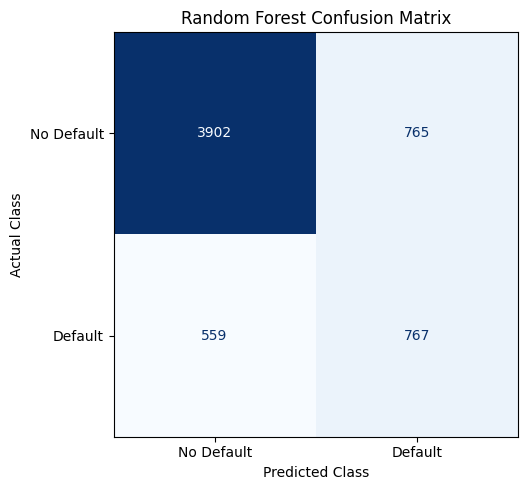

In [59]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Default", "Default"]
)

fig, ax = plt.subplots(figsize=(7, 5))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=False
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()

**Interpretation.** The Random Forest correctly classified 3,902 non-defaulting
customers and 767 defaulting customers. It incorrectly classified 765
non-defaulting customers as defaults (false positives), while 559 customers who
actually defaulted were classified as non-defaults (false negatives).

From a credit-risk perspective, the false-negative cases are particularly
important because they represent customers whose default risk was not identified
by the model. The model achieved a default-class recall of approximately 57.8%,
meaning that it identified slightly more than half of the actual defaults in the
test set. This highlights an important trade-off between identifying risky
borrowers and unnecessarily restricting customers who may repay successfully.

Consequently, the model should be interpreted as a decision-support and
risk-screening tool rather than as a standalone mechanism for automatically
approving or rejecting credit applications. Probability thresholds could also
be adjusted depending on the institution's relative costs of missed defaults
and false risk alerts.

## 8. Credit Risk Scoring and Decision Support

The selected Random Forest model produces a probability representing the estimated likelihood that a customer will default.

To make this prediction easier for a micro-lender to understand, the model probability is transformed into a simple project-specific credit score ranging from 0 to 100. The score is then grouped into risk categories and translated into an illustrative lending decision-support recommendation.

The resulting workflow is:

**Borrower Data → Default Probability → Credit Score → Risk Category → Lending Recommendation**

The scoring framework developed in this project is intended for demonstration purposes and should not be interpreted as an industry-standard credit scoring system.

### 8.1 Default Probability

The Random Forest classifier provides a predicted probability of default for each customer in the test dataset.

A higher probability indicates that the model considers the customer more likely to default, while a lower probability indicates relatively lower predicted repayment risk.

### 8.2 Credit Score Transformation

To make the model output more intuitive, the predicted probability of default is converted into a project-specific credit score ranging from 0 to 100.

The score is calculated as:

**Credit Score = (1 − Predicted Probability of Default) × 100**

Therefore:

- a higher credit score represents lower predicted default risk;
- a lower credit score represents higher predicted default risk.

This score is specific to this project and should not be confused with an established commercial or regulatory credit score.

### 8.3 Risk Categories

To make the credit scores easier to interpret, customers are grouped into three illustrative risk categories:

- **Low Risk:** Credit Score ≥ 70
- **Medium Risk:** Credit Score between 40 and 69
- **High Risk:** Credit Score < 40

These thresholds were selected for the MVP to demonstrate risk segmentation. They are not universal lending thresholds and would require calibration before use in a real financial institution.

### 8.4 Risk Category Validation

To assess whether the proposed risk categories meaningfully separate customers according to repayment risk, the actual default rate within each category was calculated.

A useful risk-scoring framework should show progressively higher observed default rates as customers move from Low Risk to Medium Risk and High Risk.

### 8.5 Lending Recommendations

To demonstrate how the credit-scoring system could support a micro-lender, each risk category is translated into a simple decision-support recommendation.

The recommendations are:

- **Low Risk → Consider for Approval**
- **Medium Risk → Manual Review**
- **High Risk → High Risk / Further Assessment**

The system deliberately avoids automatically approving or rejecting customers. Instead, the model acts as an initial risk-screening mechanism that can support human lending decisions.

## 9. Conclusions

This project developed a machine-learning credit-risk prototype for estimating the likelihood of customer default and translating that prediction into an interpretable micro-lender credit score.

Exploratory analysis showed that repayment behaviour is strongly associated with default risk. Customers with repeated repayment difficulties across several months recorded substantially higher default rates than customers with no repayment delays. Credit utilization, recent repayment status, payment amounts and credit limit also showed meaningful relationships with default outcomes.

Two classification models were evaluated: Logistic Regression and Random Forest. The Random Forest model produced the stronger overall performance, achieving approximately **77.9% accuracy**, **50.1% precision**, **57.8% recall**, **53.7% F1-score**, and **77.4% ROC-AUC**.

Feature-importance analysis showed that the most influential predictors included the most recent repayment status (`PAY_0`), the engineered `DELAY_MONTHS` feature, previous repayment-status variables, credit utilization, recent payment amount and credit limit. This indicates that historical repayment behaviour provides valuable information for identifying customers with elevated credit risk.

The model's predicted default probability was converted into a project-specific credit score ranging from 0 to 100. Customers were grouped into Low, Medium and High Risk categories. Validation of these categories showed observed default rates of approximately **8.09% for Low Risk customers**, **20.18% for Medium Risk customers**, and **57.05% for High Risk customers**.

These results demonstrate that the model can meaningfully separate customers according to relative repayment risk. The resulting scoring system can therefore serve as a prototype decision-support tool for micro-lenders, helping them identify customers who may require additional assessment before credit is extended.

The model should not, however, be used as a fully automated lending-decision system. Real-world deployment would require local borrower data, threshold calibration, fairness testing, regulatory review and continued monitoring of model performance.


## 10. Limitations and Responsible Use

### 10.1 Dataset Limitation

The dataset used in this project is not based on Nigerian micro-lending customers. It is therefore suitable for demonstrating the machine-learning methodology, but the resulting model should not be assumed to represent the repayment behaviour of Nigerian borrowers.

A production system for Nigerian micro-lenders would require locally collected and properly governed lending data.

### 10.2 Model Performance Limitation

Although the Random Forest model performed better than the Logistic Regression baseline, its predictive performance is not perfect.

The model correctly identified 767 customers who defaulted, but it failed to identify 559 actual defaulters. These false-negative cases are particularly important because they represent borrowers whose repayment risk may be underestimated.

### 10.3 Risk Threshold Limitation

The credit-score thresholds used to define Low, Medium and High Risk are illustrative thresholds created for the MVP.

They should not be interpreted as universal lending standards. A real financial institution would need to determine suitable thresholds based on expected financial loss, risk appetite, portfolio characteristics and regulatory requirements.

### 10.4 Fairness Considerations

Credit-scoring systems can create unfair outcomes if models rely too heavily on demographic characteristics or historical data containing social or institutional bias.

For this reason, the primary predictive model in this project emphasizes financial and repayment-behaviour variables rather than demographic characteristics.

Before real-world deployment, the model should be tested for unequal performance across relevant customer groups and reviewed to ensure that protected or sensitive characteristics do not create unfair lending outcomes.

### 10.5 Decision-Support Use

The system is intended as a decision-support prototype rather than an automated loan approval system.

Final lending decisions should incorporate verified borrower information, affordability assessment, lender policies, human review where necessary and applicable regulatory requirements.

### 10.6 Future Improvements

Future versions of the project could be improved by:

* using Nigerian micro-lending data;
* performing more extensive model tuning and cross-validation;
* evaluating additional machine-learning algorithms;
* calibrating predicted probabilities;
* testing alternative decision thresholds;
* conducting formal fairness analysis;
* adding model-explanation techniques for individual applicants;
* monitoring model performance over time after deployment.
